In [2]:
import numpy
import torchvision

train = torchvision.datasets.MNIST('mnist', train = True, download = False)
test = torchvision.datasets.MNIST('mnist', train = False, download = False)

train_images = numpy.array([numpy.array(item[0]) / 255 for item in train])
train_labels = numpy.array([item[1] for item in train])
test_images = numpy.array([numpy.array(item[0]) / 255 for item in test])
test_labels = numpy.array([item[1] for item in test])

In [3]:
import klein

patch_cloud = klein.build_patch_cloud(train_images, max_points = 5000, seed=42)
patch_cloud.shape

(5000, 8)

topology experiments:   0%|          | 0/3 [00:00<?, ?it/s]

# 5000
UU
^
!
@
$
^
!
@
$
^
!
@


topology experiments:  33%|███▎      | 1/3 [02:01<04:03, 121.86s/it]

$
&
# 5000
UU
^
!
@
$
^
!
@
$
^
!
@


topology experiments:  67%|██████▋   | 2/3 [04:20<02:11, 131.47s/it]

$
&
# 5000
UU
^
!
@
$
^
!
@
$
^
!
@


topology experiments: 100%|██████████| 3/3 [05:33<00:00, 111.23s/it]

$
&


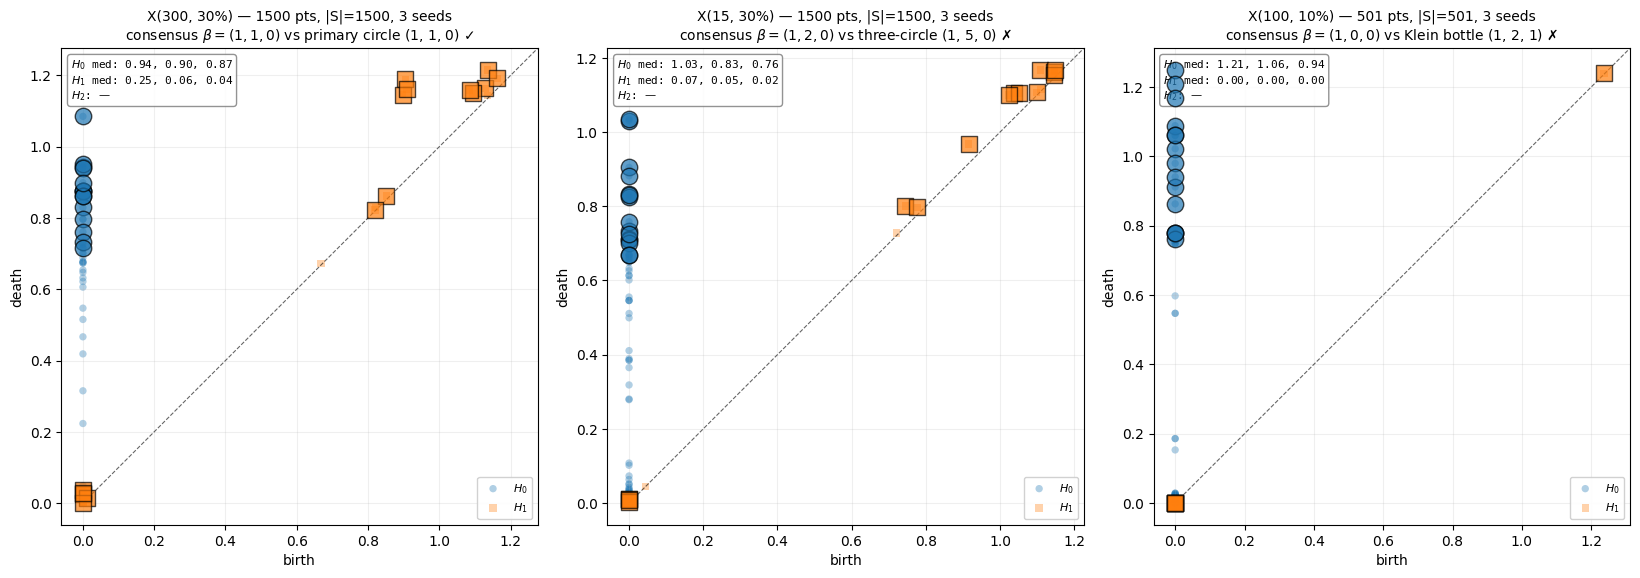

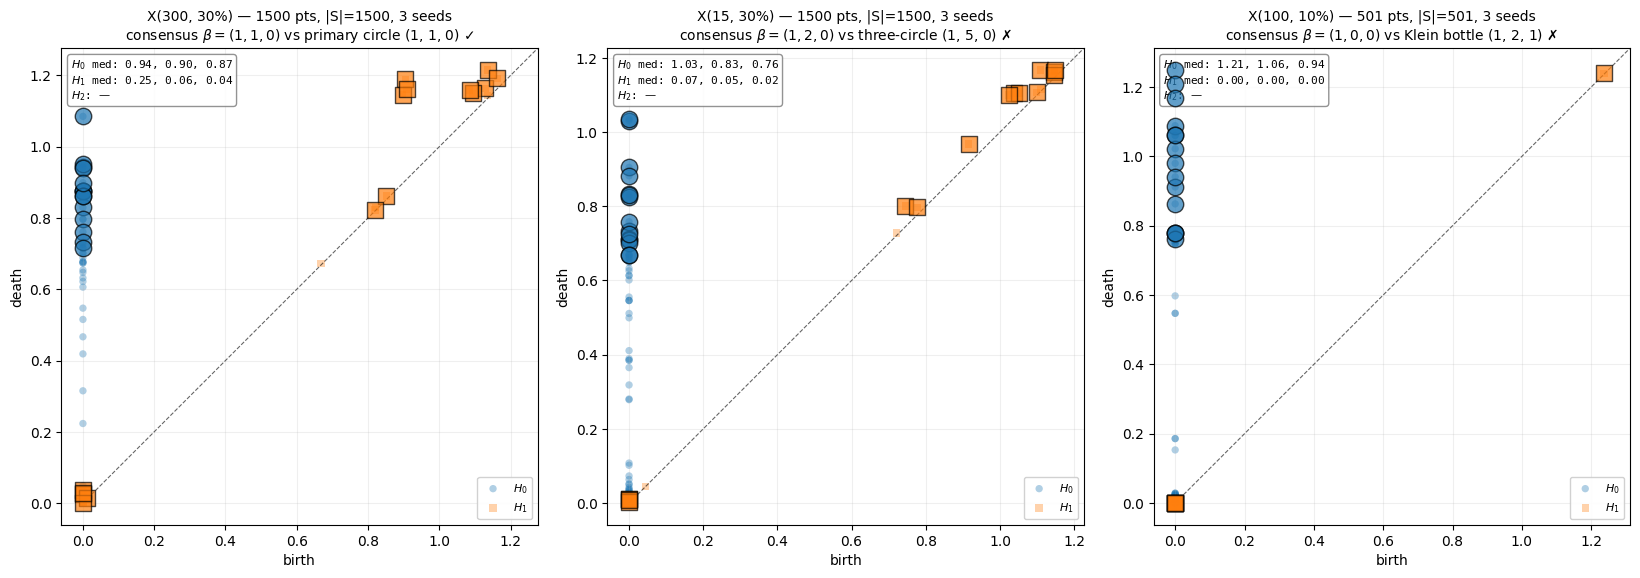

In [4]:
results = klein.run_topology_experiments(
    patch_cloud,
    configs = [(300, 0.30), (15, 0.30), (100, 0.10)],
    n_landmarks = 100,
    subsample_size = 10000,
    n_seeds = 3,
    denoise_k = 20,
    denoise_iterations = 2,
)
klein.plot_topology_results(results)

In [1]:
fe = klein.FeatureExtractor()
train_features = fe.fit_transform(train_images)
test_features = fe.transform(test_images)

KeyboardInterrupt: 

Accuracy: 0.9756
F1 macro: 0.9754


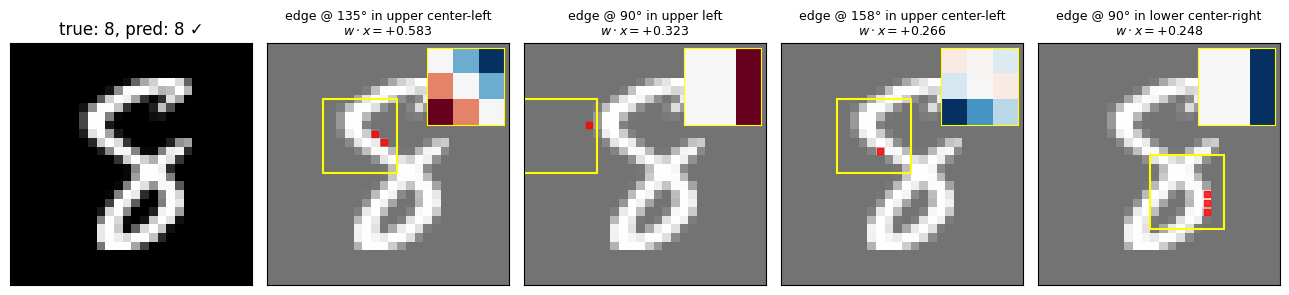

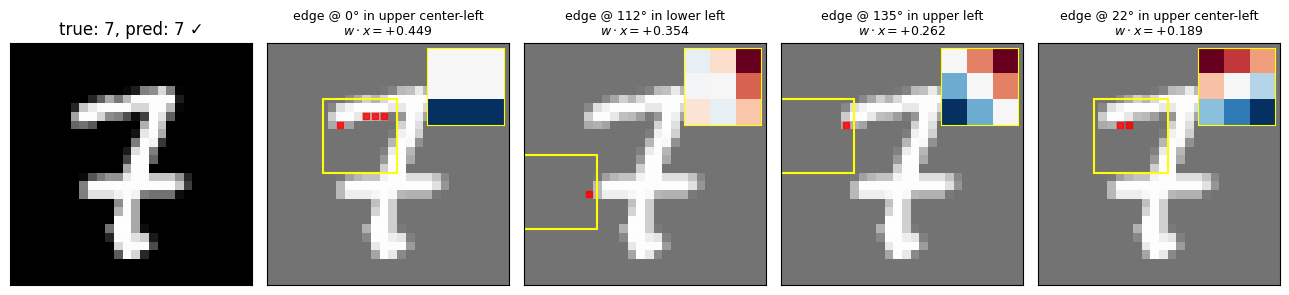

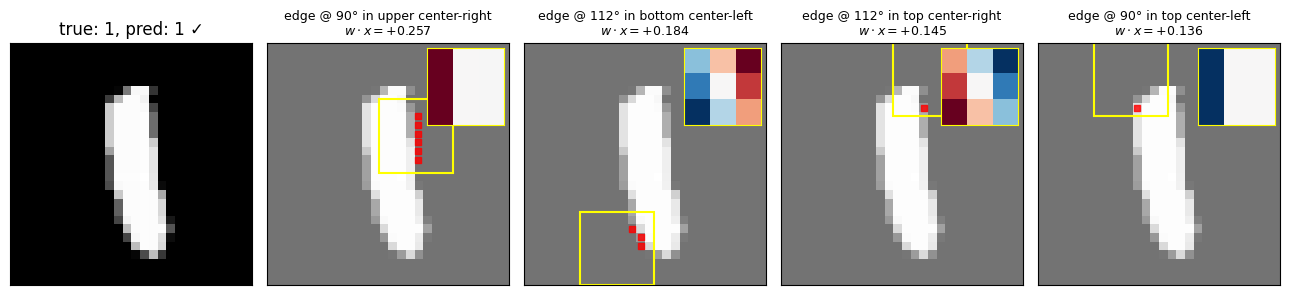

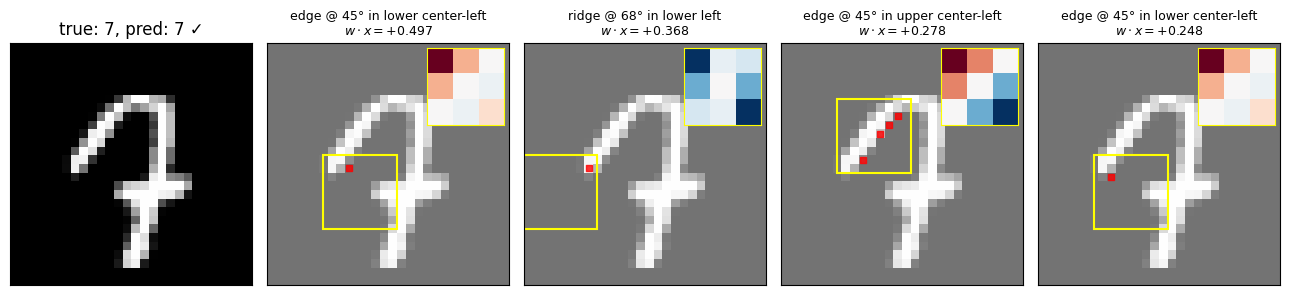

In [5]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

clf = LinearSVC(C = 5.0, max_iter = 3000, dual = False)
clf.fit(train_features, train_labels)
preds = clf.predict(test_features)
print(f"Accuracy: {accuracy_score(test_labels, preds):.4f}")
print(f"F1 macro: {f1_score(test_labels, preds, average = 'macro'):.4f}")

for i in numpy.random.RandomState(0).choice(len(test_images), 4, replace = False):
    expl = klein.explain_prediction(clf, fe, test_images[i], true_label = int(test_labels[i]))
    klein.plot_explanation(test_images[i], expl, fe)